## Market Prior (Implied Returns) Validation — Black–Litterman

### Objective
Derive the **market-implied equilibrium returns** Pi and perform an **equilibrium check**:

- Compute the market prior via

Pi = lambda * Sigma * w_mkt

- Verify mathematical consistency by solving the mean–variance utility problem using (Pi, Sigma, lambda) and recovering w_mkt.

### Universe
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']

### Notation
- Sigma: (annualized) covariance matrix of returns
- w_mkt: market-cap weights (sum to 1)
- lambda: risk aversion
- Pi: implied equilibrium returns (annualized)


In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we run from project root (so `data/raw` resolves correctly)
if Path.cwd().name in {"notebooks", "research"}:
    os.chdir("..")

project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"CWD: {Path.cwd()}")

from src.data.data_manager import DataManager
from src.data.data_downloader import YahooDownloader
from src.analytics.optimizer import MeanVarianceOptimizer
from src.analytics.black_litterman import BlackLittermanModel

import yfinance as yf

CWD: c:\Users\reymo\quant-portfolio


## Step 1 — Data acquisition (Adjusted Close)

We use the project’s storage layer (`DataManager`) to load OHLCV data from `data/raw`. 

We then build a clean price matrix P_t and compute simple daily returns:


R_t = (P_t / P_{t-1}) - 1



In [2]:

start_date = "2019-01-01"
end_date = "2023-12-31"

dm = DataManager(base_dir="data/raw")
downloader = YahooDownloader()

tickers = dm.list_existing_tickers()

close_frames: list[pd.Series] = []

for t in tickers:
    print(f"Loading {t}...", end=" ")
    try:
        df_t = dm.load_ticker(t)
        print("✓ (from cache)")
    except (FileNotFoundError, RuntimeError) as e:
        raise(f"FileNotFoundError, make sure {t} is in the data/raw folder")

    df_t = df_t.copy()

    # Defensive: ensure datetime index
    if not isinstance(df_t.index, pd.DatetimeIndex):
        df_t.index = pd.to_datetime(df_t.index)

    # Handle case where columns might still be MultiIndex after load
    if isinstance(df_t.columns, pd.MultiIndex):
        df_t.columns = df_t.columns.get_level_values(-1)  # Get the last level (Field names)

    if "Close" not in df_t.columns:
        raise ValueError(f"Expected a 'Close' column for {t}, got columns={list(df_t.columns)}")

    close_frames.append(df_t["Close"].rename(t))

print(f"\n✓ Loaded {len(close_frames)} tickers")

prices = pd.concat(close_frames, axis=1).sort_index().ffill()
returns = prices.pct_change().dropna(how="any")

print(f"Price matrix shape: {prices.shape}")
print(f"Returns matrix shape: {returns.shape}")

prices.tail(), returns.describe().T

Loading AAPL... ✓ (from cache)
Loading AIR.PA... ✓ (from cache)
Loading AMZN... ✓ (from cache)
Loading BNP.PA... ✓ (from cache)
Loading DG.PA... ✓ (from cache)
Loading GOOGL... ✓ (from cache)
Loading JNJ... ✓ (from cache)
Loading JPM... ✓ (from cache)
Loading KO... ✓ (from cache)
Loading MC.PA... ✓ (from cache)
Loading MSFT... ✓ (from cache)
Loading NVDA... ✓ (from cache)
Loading OR.PA... ✓ (from cache)
Loading PG... ✓ (from cache)
Loading RMS.PA... ✓ (from cache)
Loading SAN.PA... ✓ (from cache)
Loading SU.PA... ✓ (from cache)
Loading TSLA... ✓ (from cache)
Loading TTE.PA... ✓ (from cache)
Loading XOM... ✓ (from cache)

✓ Loaded 20 tickers
Price matrix shape: (1034, 20)
Returns matrix shape: (1033, 20)


(                  AAPL      AIR.PA        AMZN     BNP.PA       DG.PA  \
 Date                                                                    
 2023-12-22  191.788773  134.040451  153.419998  53.640373  105.480713   
 2023-12-26  191.243912  134.040451  153.410004  53.640373  105.480713   
 2023-12-27  191.342987  134.021210  153.339996  53.623352  105.536049   
 2023-12-28  191.768951  134.271149  153.380005  53.163647  104.724510   
 2023-12-29  190.728775  134.367279  151.940002  53.282825  104.853630   
 
                  GOOGL         JNJ         JPM         KO       MC.PA  \
 Date                                                                    
 2023-12-22  140.428955  146.213623  159.387558  54.969810  707.017151   
 2023-12-26  140.458725  146.853165  160.330185  55.196018  707.017151   
 2023-12-27  139.317337  147.050705  161.291840  55.337406  704.812866   
 2023-12-28  139.178375  147.266998  162.148758  55.375107  700.595886   
 2023-12-29  138.642471  147.417496 

## Step 2 — Covariance Sigma via Ledoit–Wolf shrinkage (project implementation)

We construct Sigma using the same shrinkage routine as the rest of the project (the stabilizer inside MeanVarianceOptimizer).

To keep units consistent with the benchmark return (8% annual), we **annualize** the covariance:

Sigma_ann = 252 * Sigma_daily


In [3]:
mvo = MeanVarianceOptimizer(returns)
delta = mvo.calculate_optimal_delta()

sigma_daily = mvo._apply_ledoit_wolf_shrinkage(delta)
Sigma_daily = pd.DataFrame(sigma_daily, index=tickers, columns=tickers)
Sigma_ann = 252.0 * Sigma_daily

delta, Sigma_ann.round(6).iloc[:3, :3]

(np.float64(0.022494605663457422),
             AAPL    AIR.PA      AMZN
 AAPL    0.110025  0.031125  0.075107
 AIR.PA  0.031125  0.199783  0.014824
 AMZN    0.075107  0.014824  0.137937)

## Step 3 — Market weights w_mkt from market caps

We approximate the market portfolio over the universe by using current market capitalizations.


(w_mkt)_i = MktCap_i / (sum of all MktCap_j)


This yields a fully-invested benchmark vector aligned to (Sigma)’s index.


In [4]:
def get_market_caps(tickers: list[str]) -> pd.Series:
    caps: dict[str, float] = {}
    for t in tickers:
        tk = yf.Ticker(t)

        cap = None
        # Prefer fast_info if available
        try:
            cap = tk.fast_info.get("marketCap")
        except Exception:
            cap = None

        if cap is None:
            try:
                cap = tk.info.get("marketCap")
            except Exception:
                cap = None

        if cap is None:
            raise RuntimeError(f"Could not fetch market cap for {t}.")

        caps[t] = float(cap)

    return pd.Series(caps, name="market_cap")

market_caps = get_market_caps(tickers).reindex(tickers)
w_mkt = (market_caps / market_caps.sum()).rename("w_mkt")

market_caps, w_mkt, w_mkt.sum()

(AAPL      3.813818e+12
 AIR.PA    1.526660e+11
 AMZN      2.558169e+12
 BNP.PA    1.019473e+11
 DG.PA     6.727402e+10
 GOOGL     4.093897e+12
 JNJ       5.475123e+11
 JPM       8.327129e+11
 KO        3.219573e+11
 MC.PA     2.714856e+11
 MSFT      3.195174e+12
 NVDA      4.653442e+12
 OR.PA     2.065740e+11
 PG        3.552155e+11
 RMS.PA    2.127129e+11
 SAN.PA    9.594206e+10
 SU.PA     1.362266e+11
 TSLA      1.615084e+12
 TTE.PA    1.310627e+11
 XOM       5.963072e+11
 Name: market_cap, dtype: float64,
 AAPL      0.159180
 AIR.PA    0.006372
 AMZN      0.106772
 BNP.PA    0.004255
 DG.PA     0.002808
 GOOGL     0.170870
 JNJ       0.022852
 JPM       0.034755
 KO        0.013438
 MC.PA     0.011331
 MSFT      0.133359
 NVDA      0.194224
 OR.PA     0.008622
 PG        0.014826
 RMS.PA    0.008878
 SAN.PA    0.004004
 SU.PA     0.005686
 TSLA      0.067410
 TTE.PA    0.005470
 XOM       0.024888
 Name: w_mkt, dtype: float64,
 np.float64(0.9999999999999997))

## Step 4 — Risk aversion lambda from a benchmark return and market variance

We use the standard CAPM-style approximation:

lambda = (E[R_mkt] - r_f) / Var(R_mkt)

Implementation details:
- E[R_mkt]: set to an annual benchmark return of **8%**.
- Var(R_mkt): estimated from the **variance of the market-portfolio return** of our universe using Sigma_ann:

Var(R_mkt) ≈ w_mkt^T * Sigma_ann * w_mkt


In [5]:
bl = BlackLittermanModel(risk_free_rate=0.04)

benchmark_return = 0.08
var_mkt = float(w_mkt.T @ Sigma_ann @ w_mkt)

lam = bl.calculate_risk_aversion(benchmark_return=benchmark_return, benchmark_var=var_mkt)

pd.Series({
    "rf": bl.rf,
    "benchmark_return": benchmark_return,
    "var_mkt": var_mkt,
    "lambda": lam,
})

rf                  0.040000
benchmark_return    0.080000
var_mkt             0.090643
lambda              0.441293
dtype: float64

## Step 5 — Market prior (Implied returns) Pi

Given lambda, Sigma, and w_mkt, the equilibrium (market-implied) returns are

Pi = lambda * Sigma * w_mkt

Because we work with pandas objects, the multiplication is performed with **explicit index alignment** (same ticker ordering for Sigma and w_mkt).


In [6]:
Pi_ann = bl.calculate_implied_returns(
    covariance=Sigma_ann,
    market_weights=w_mkt,
    risk_aversion=lam
)

hist_ann = (returns.mean() * 252.0).rename("Historical Annualized Return")

pd.concat([hist_ann, Pi_ann], axis=1)

,Historical Annualized Return,Implied Returns
AAPL,0.290910,0.037455
AIR.PA,0.119021,0.016764
AMZN,0.183832,0.037615
BNP.PA,0.154691,0.016058
DG.PA,0.114335,0.014538
GOOGL,0.228872,0.036859
JNJ,0.064252,0.010665
JPM,0.132534,0.023511
KO,0.071837,0.013637
MC.PA,0.195442,0.018259


## Step 6 — Equilibrium check (weight recovery)

We now solve the mean–variance utility problem:

maximize: Pi^T * w - (lambda/2) * w^T * Sigma * w
subject to: sum(w) = 1

If Pi = lambda * Sigma * w_mkt and constraints are not binding, the optimizer should recover the market weights:

w_optimized ≈ w_mkt


In [7]:
w_opt = mvo.solve(
    expected_returns=Pi_ann,
    covariance=Sigma_ann,
    risk_aversion=lam,
    long_only=True,
)

comparison = pd.concat([w_mkt.rename("w_mkt"), w_opt.rename("w_optimized")], axis=1)
comparison["abs_diff"] = (comparison["w_optimized"] - comparison["w_mkt"]).abs()

comparison, comparison["abs_diff"].max()

(           w_mkt  w_optimized      abs_diff
 AAPL    0.159180     0.159175  4.371292e-06
 AIR.PA  0.006372     0.006375  3.300845e-06
 AMZN    0.106772     0.106771  7.520733e-07
 BNP.PA  0.004255     0.004252  2.719370e-06
 DG.PA   0.002808     0.002805  3.150002e-06
 GOOGL   0.170870     0.170873  3.820347e-06
 JNJ     0.022852     0.022857  5.571682e-06
 JPM     0.034755     0.034760  4.037953e-06
 KO      0.013438     0.013429  8.965085e-06
 MC.PA   0.011331     0.011338  6.763364e-06
 MSFT    0.133359     0.133353  5.977469e-06
 NVDA    0.194224     0.194226  1.881839e-06
 OR.PA   0.008622     0.008618  3.872275e-06
 PG      0.014826     0.014831  5.475427e-06
 RMS.PA  0.008878     0.008873  5.010675e-06
 SAN.PA  0.004004     0.004006  1.527930e-06
 SU.PA   0.005686     0.005692  6.068581e-06
 TSLA    0.067410     0.067410  2.511022e-07
 TTE.PA  0.005470     0.005463  7.275773e-06
 XOM     0.024888     0.024892  3.394943e-06,
 np.float64(8.965085149865992e-06))

## Step 7 — Visualizations

- **Return comparison**: historical annualized mean vs implied equilibrium return.
- **Weight recovery**: w_mkt vs w_optimized (should match up to numerical tolerance).


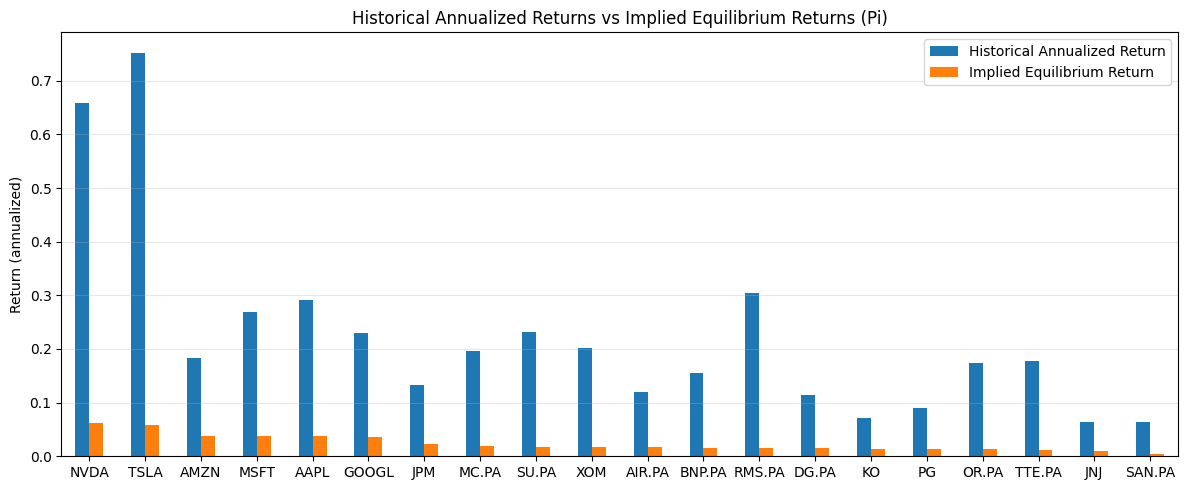

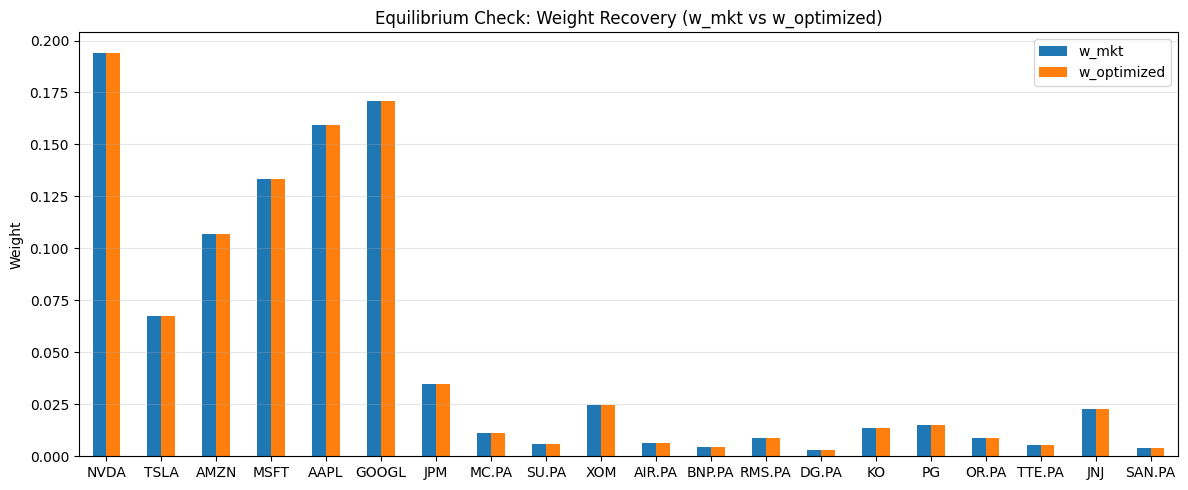

In [8]:
# --- Bar chart: Historical vs Implied ---
plot_df = pd.concat([hist_ann, Pi_ann.rename("Implied Equilibrium Return")], axis=1)
plot_df = plot_df.sort_values("Implied Equilibrium Return", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Historical Annualized Returns vs Implied Equilibrium Returns (Pi)")
ax.set_ylabel("Return (annualized)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Weight recovery chart ---
weights_df = comparison[["w_mkt", "w_optimized"]].copy()
weights_df = weights_df.loc[plot_df.index]  # same ordering as plot above

ax = weights_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("Equilibrium Check: Weight Recovery (w_mkt vs w_optimized)")
ax.set_ylabel("Weight")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation

- If the **max absolute weight error** is near machine precision (e.g., (less than 10^-6)), the equilibrium identity is numerically validated under the project’s constraints.
- If the recovery is imperfect, the usual culprits are:
  - Unit mismatch (daily vs annual inputs),
  - Constraint binding (e.g., long-only causing corner solutions),
  - Index misalignment between (Sigma) and (w).


## Step 8 - Adding Views


In [24]:
tickers = dm.list_existing_tickers()
tau = 0.025
bl = BlackLittermanModel()
# Add Views
# View 1: Absolute - AAPL will return 7%
bl.add_view({'AAPL': 1.0}, 0.07, confidence_score=0.3)

# View 2: Relative Basket - (AAPL + MSFT) will outperform GOOGL by 2%
# Weights must sum to zero for relative trades
bl.add_view({'AAPL': 0.5, 'MSFT': 0.5, 'GOOGL': -1.0}, 0.02, confidence_score=0.5)

# 3. Generate Matrices
P, Q = bl._build_matrices(tickers)
Omega = bl.compute_omega(P, Sigma_ann.values, tau)

print("--- Pick Matrix (P) ---")
print(P)
print("\n--- View Vector (Q) ---")
print(Q)
print("\n--- Uncertainty Matrix (Omega) ---")
print(np.round(Omega, 6))

--- Pick Matrix (P) ---
[[ 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0. ]
 [ 0.5  0.   0.   0.   0.  -1.   0.   0.   0.   0.   0.5  0.   0.   0.
   0.   0.   0.   0.   0.   0. ]]

--- View Vector (Q) ---
[[0.07]
 [0.02]]

--- Uncertainty Matrix (Omega) ---
[[0.006418 0.      ]
 [0.       0.001235]]


In [25]:
E = bl.get_posterior_returns(Pi_ann, Sigma_ann, P, Q, Omega, tau)
print(E)

AAPL     0.050
AIR.PA   0.018
AMZN     0.043
BNP.PA   0.018
DG.PA    0.016
GOOGL    0.037
JNJ      0.014
JPM      0.028
KO       0.017
MC.PA    0.021
MSFT     0.046
NVDA     0.072
OR.PA    0.015
PG       0.017
RMS.PA   0.018
SAN.PA   0.005
SU.PA    0.021
TSLA     0.069
TTE.PA   0.013
XOM      0.020
dtype: float64


In [28]:
black_litterman_weights = mvo.solve(expected_returns=E, covariance=Sigma_ann, risk_aversion=lam, max_weights=0.25)
tangency = mvo.find_tangency_portfolio(risk_free_rate=0.04, risk_free_rate_is_annual=True)
portfolio_weights = tangency['weights']


# Option B: If some are dicts, convert to Series with same index (tickers)
comparison = pd.DataFrame({
    "market_weight": w_mkt,
    "tangency": pd.Series(portfolio_weights),      # weights from get_optimal_weights is dict
    "black_litterman": black_litterman_weights,
})

# Round to 3 decimals, then format so pandas doesn't use scientific notation
comparison_rounded = comparison.round(3)
pd.options.display.float_format = '{:.3f}'.format
comparison_rounded.sort_values(by='market_weight', ascending=False, inplace=True)
comparison_rounded

,market_weight,tangency,black_litterman
NVDA,0.194,0.302,0.237
GOOGL,0.171,0.000,0.000
AAPL,0.159,0.000,0.250
MSFT,0.133,0.000,0.250
AMZN,0.107,0.000,0.090
TSLA,0.067,0.203,0.089
JPM,0.035,0.000,0.055
XOM,0.025,0.075,0.012
JNJ,0.023,0.000,0.000
PG,0.015,0.000,0.017


In [43]:
# Pass the annualized covariance you used in the BL model
te_bl = mvo.compute_active_error(Sigma_ann, comparison['market_weight'], comparison['black_litterman'])
as_bl = mvo.compute_active_share(comparison['market_weight'], comparison['black_litterman'])

print(f"BL Active Share: {as_bl:.2%}")
print(f"BL Annualized Tracking Error: {te_bl:.2%}")


BL Active Share: 29.44%
BL Annualized Tracking Error: 5.49%
